# IMDB Movie Review Sentiment Analysis (unsupervised and supervised learning)

**Author: Sheldon Mellett** 

**Module: PDAN8411w - Programming for Data Analytics**

**Assessment: Summative Assignment**

# Project Outline

| Section | Sub-sections |
| :--- | :--- |
| **[1. Introduction](#1-introduction)** | <ul><li>[1.1. Scope](#11-scope)</li><li>[1.2. Objectives](#12-objectives)</li><li>[1.3. Limitations](#13-limitations)</li><li>[1.4. Dataset Overview and Algorithm Justification](#14-dataset-overview-and-algorithm-justification)</li><li>[1.5. Analysis Plan](#15-analysis-plan)</li></ul> |
| **[2. Dataset and Data Quality Assessment](#2-dataset-and-data-quality-assessment)** | <ul><li>[2.1. Importing Libraries](#21-importing-libraries)</li><li>[2.2. Loading Data and Verifying Shape](#22-loading-data-and-verifying-shape)</li><li>[2.3. Data Quality Assessment and Preprocessing](#23-data-quality-assessment-and-preprocessing)</li></ul> |
| **[3. Preprocessing](#3-preprocessing)** | <ul><li>[3.1. Instantiating the Pipeline](#31-instantiating-the-pipeline)</li><li>[3.2. Sampling the Dataset](#32-sampling-the-dataset)</li></ul> |
| **[4. Model Training and Optimising](#4-model-training-and-optimising)** | <ul><li>[4.1. Initialising LDA](#41-initialising-lda)</li><li>[4.2. Training/fitting LDA](#42-trainingfitting-lda)</li><li>[4.3. Evaluating findings of LDA](#43-evaluating-findings-of-lda)</li></ul> |
| **[5. Supervised Learning Algorithms](#5-supervised-learning-algorithms)** | <ul><li>[5.1. Preprocessing text data](#51-preprocessing-text-data)</li><li>[5.2. Fitting the models](#52-fitting-the-models)</li><li>[5.3. Model Coefficients](#53-model-coefficients)</li><li>[5.4. Performance analysis](#54-performance-analysis)</li><li>[5.5. Evaluation](#55-evaluation)</li></ul> |
| **[6. Conclusion](#6-conclusion)** | <ul><li>[6.1. Recommendations](#61-recommendations)</li></ul> |
| **[7. References](#7-references)** | *None* |

<div style="page-break-after: always;"></div>


#### 1. Introduction
#### - **1.1. Scope**

**The primary focus** of this notebook is to perform a high-accuracy sentiment analysis on movie reviews using both **unsupervised** and **supervised** learning approaches. The analysis makes utilises the **IMDB movie review dataset**, which contains 50,000 records with two columns:

- **review (independent variable)**: the text data from the reviews 
- **sentiment (dependent variable)**: the labelled sentiment of the reviews (positve or negative)

This notebook first conducts unsupervised learning using **Latent Dirichlet Allocation (LDA)** to identify underlying topics and themes within the movie reviews. Following this, three supervised binary classification models (**Logistic Regression**, **, Multinomial Naive Bayes**, **Support Vector Machine**) are built and compared to identify the highest performing algorithm for sentiment-based datasets. 

#### - **1.2. Objectives**

**Primary**
- **Develop** accurate sentiment analysis models for movie reviews using supervised machine learning algorithms
- **Identify** the underlying themes within the movie reviews using an unsupervised machine learning algorithm

**Secondary**
- **Compare** the performance of three different classification algorithms across multiple different evaluation metrics (all metrics mentioned in the planning phase)
- **Find** the best performing classification algorithms for sentiment-based movie review datasets
- **Evaluate** the preprocessing and modelling phases used in this dataset and provide recommendations for future researchers

#### - **1.3. Limitations**

- **Binary review sentiment classification:** the dataset has two classes (positive or negative)
- **Single-domain sentiment analysis:** this uses only one domain (text-based reviews)
- **Sample-size:** due to time and computational constraints, this notebook only uses a portion (2500 postive and 2500 negative) of the 50,000 data entrees in the dataset

(James et al., 2023).

#### - **1.4. Dataset Overview and Algorithm Justification**

**Dataset**
- **This** dataset contains positive and negative movie reviews from IMDB and can be found at the following link: https://www.kaggle.com/code/lakshmi25npathi/sentiment-analysis-of-imdb-movie-reviews

**Algorithm justification**
- **Latent dirichlet allocation** is chosen because it can identify the underlying themes within the text review data. The findings are also easy to interpret, making this algorithm one of the most popular unsupervised models for text-based analysis. 
- **Logistic regression** is selected because of it's simplicity, interpretability, and performance for binary classification. This algorithm is often chosen as a baseline for classification problems.
- **Multinomial naive bayes** is selected because it is very efficient with sparse data and because it does not need much computational power to run. This algorithm is one of the most popular algorithms use for text classification.
- **Support vector machine** is used due to it's ability to model non-linear data. No data distribution assumptions are made which is why it performs so well on high-dimensional data.

(Müller & Guido, 2016; James et al., 2023).

#### - **1.5. Analysis Plan**

1. **Identify** the scope, objectives, and limitations as well as the justification of algorithms associated with the project.
2. **Import** libraries and load dataset.
3. **Conduct** exploratory data analysis.
4. **Preprocess** and prep text data for modelling by applying text cleaning pipeline.
5. **Train** LDA model and visualise findings.
6. **Train** supervised classification models then evaluate and compare the findings to identify the most powerful performer.
7. **Suggest** future recommendations for researchers conducting unsupervised and supervised sentiment analysis.    

#### 2. Dataset and Data Quality Assessment
#### - **2.1. Importing Libraries**

In [1]:
# import libraries for data manipulation, handling dataframes, numerical operations 
import pandas as pd 
import numpy as np
import sklearn 

# import libraries for plotting charts
import matplotlib.pyplot as plt 
import seaborn as sns

# import libraries used for Natural Language Processing
import string
import nltk

# import libraries used for NLP preprocessing
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline

# import libraries used for modelling and evaluation
from sklearn.model_selection import train_test_split 
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix

# hide ugly warning messages
import warnings
warnings.filterwarnings('ignore')

**The libraries** being imported allow: 
- **data manipulation** (pandas, numpy, sklearn)
- **visualisations** (matplotlib, seaborn)
- **natural language processing** (string, nltk)
- **text preprocessing** (count vectorizer, tfid vectorizer, standard scaler, pipeline)
- **machine learning modelling** (train-test-split, LDA, logistic regression, multinomialNB, linear SVC, gridsearchCV)
- **model evaluation** (classification report, roc curve, auc score, confusion matrix).

(Müller & Guido, 2016).

#### - **2.2. Loading Data and Verifying Shape**

In [2]:
# import and view dataset
df = pd.read_csv('IMDB Dataset.csv')

# check the first five records
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [4]:
df.dtypes

review       object
sentiment    object
dtype: object

**This initial inspection** confirms that the dataset has two columns (review, sentiment) with a total of 50,000 records for each column. **The review column** has 49,582 unique reviews, meaning that 418 reviews are duplicates and must be addressed in future. The most common review appears 5 times within the review column. **Additionally**, the sentiment column is perfectly balanced, with 25,000 reviews being positive and 25,000 review being negative 

**The next section** is an in-depth analysis of data quality. This involves checking for missing values as well as the character length of reviews within the dataset.   

#### - **2.3. Data Quality Assessment and Preprocessing**

- **Missing and Duplicated Values**

In [5]:
# check for missing values 
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [6]:
# check for duplicates
print(f"Duplicates found: {df.duplicated().sum()}")

Duplicates found: 418


- **Descriptive analysis**

In [15]:
print(f"\n Review Length:")
df['review_length'] = df['review'].str.len()
print(f"   Min: {df['review_length'].min()} characters")
print(f"   Max: {df['review_length'].max()} characters")
print(f"   Mean: {df['review_length'].mean():.2f} characters")
print(f"   Median: {df['review_length'].median()} characters")
print(f"   Std Dev: {df['review_length'].std():.2f} characters")


 Review Length:
   Min: 32 characters
   Max: 13704 characters
   Mean: 1309.43 characters
   Median: 970.0 characters
   Std Dev: 989.73 characters


- **Check for inconsistencies**

In [9]:
# adapted from code generate from google's ai: https://share.google/aimode/TwRvCpwci136uggiB
# HTML tags
html = df['review'].str.contains('<').sum()
print(f"HTML tags: {html} ({html/len(df)*100:.1f}%)")

# Punctuation
punct = df['review'].str.contains(r'[^\w\s]', regex=True).sum()
print(f"Punctuation: {punct} ({punct/len(df)*100:.1f}%)")

# Uppercase letters
upper = df['review'].str.contains(r'[A-Z]').sum()
print(f"Uppercase: {upper} ({upper/len(df)*100:.1f}%)")

# Numbers
nums = df['review'].str.contains(r'\d').sum()
print(f"Numbers: {nums} ({nums/len(df)*100:.1f}%)")

HTML tags: 29210 (58.4%)
Punctuation: 49996 (100.0%)
Uppercase: 49780 (99.6%)
Numbers: 28005 (56.0%)


**This dataset** has no missing values but the inspection found that the dataset contains 418 duplicates. These duplicates do not need to be addressed because this project only makes use of 20% of the dataset due to resource limitations. This analysis shows no cap is needed on review length because most reviews are between 150-180 words and overly lengthy reviews are rare. **Furthermore**, results show that the review text needs to be thoroughly cleaned because most of the dataset contains information like HTML tags, punctuation, inconsistent letter casing and numbering which will affect the performance of the machine learning algorithms in the next step. 

**The next section** will initialise a pipeline that processes the dataset by removing factors like HTML tags and special characters. The dataset will then be checked for numbers present in the review column as well as label errors in the sentiment column. Additionally, any other issues such as case sensitivity and stop words will also be addressed using the pipeline. 

(Murel & Kavlakoglu, 2025).

#### 3. Preprocessing
#### - **3.1. Instantiating the Pipeline**

In [12]:
# adapted from cleanmytext pipeline on arc
import string
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download('wordnet')
nltk.download('stopwords')

# initialise functions
lemmatizer = WordNetLemmatizer()

# loading stopwords
stopwords_list = set(stopwords.words('english'))

# removing html tags
def remove_html_tags(text):
    if not isinstance(text, str):
        return ""
    clean = re.sub(r'<[^>]+>', '', text)
    return clean

def html_stripper(data):
    X_html_free = data.apply(lambda x: remove_html_tags(x))
    return X_html_free

# removing numbers 
def remove_numbers(text):
    if not isinstance(text, str):
        return ""
    return re.sub(r'\d+', ' ', text)

def number_stripper(data):
    X_numbers_free = data.apply(lambda x: remove_numbers(x))
    return X_numbers_free

# cleaning word punctuation 
def remove_punctuation(text):
    punctuationfree = "".join([i for i in text if i not in string.punctuation])
    return punctuationfree

# cleaning sentence punctuation 
def punctionstripper(data):
    X_punctuation_free = data.apply(lambda x : remove_punctuation(x))
    return X_punctuation_free

# standardising lettercase across dataset
def lower_case_text(data):
    text = data.apply(lambda x: x.lower())
    return text

# splitting strings into a list of words
def tokenize(text):
    return text.split()

# tokenizing across the whole dataset
def create_tokens(data):
    tokens = data.apply(lambda x : tokenize(x))
    return tokens

# filtering out stopwords
def stopwords_stripper(data,stopwords_list):
    output= data.apply (lambda token_list: [i for i in token_list if i not in stopwords_list])
    return output

# lemmatizing each token
def lemmatize_tokens(token_list):
    if not token_list:
        return token_list
    return [lemmatizer.lemmatize(i.lower()) for i in token_list]
    
# join tokens back into one list
def convert_to_string_data(data):
    X_final_text = data.apply(lambda token_list: ' '.join([str(x) for x in token_list]))
    return X_final_text

def clean_pipeline(data, stopwords_list):
    data = html_stripper(data)  
    data = number_stripper(data) 
    data = punctionstripper(data)
    data = lower_case_text(data)
    data = create_tokens(data)
    data = stopwords_stripper(data, stopwords_list)
    data = data.apply(lemmatize_tokens)  
    return convert_to_string_data(data)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sheld\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sheld\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**This pipeline** is made up of many different functions used to clean and prep the text data for analysis:
- **HTML tag removal**: Removes characters like `<br />` that would mess up tokenization.

- **Punctuation removal**: Removes all punctuation characters to focus on the words only. 

- **Lowercase standardization**: Converts all text to lowercase to ensure consistency.

- **Tokenization**: Splits reviews into individual words.

- **Stopword removal**: Filters out words, such as 'the' or 'and', that have no sentimental meaning.

- **Lemmatization**: Converts all words to their base form.

- **String reconstruction**: Joins tokens back into a single string for vectorization.

Each function handles a specific preprocessing step, with the final pipeline combining all 7 steps to ensure efficiency.

**The next step** involves sampling the dataset, applying the pipeline, and inspecting whether the pipeline cleaned the dataset as expected.

#### - **3.2. Sampling the Dataset**

In [14]:
# sampling dataset
df_sample = df.sample(frac=0.10, random_state=42).copy()

# keeping a copy for comparison
raw_text_series = df_sample['review'].copy()

**10% of the dataset** is used as a sample as this allows for effective modelling while also ensuring that the resource limitations are met. **The next section** involves modelling the cleaned dataset sample using both unsupervised and supervised learning algorithms.

#### - **3.3. Utilising the Pipeline**

In [15]:
# creating a new clean review column 
df_sample['cleaned_review'] = clean_pipeline(df_sample['review'], stopwords_list)
cleaned_text_series = df_sample['cleaned_review']

- **Check that the pipeline worked**

In [23]:
#### adapted from code generate from google's ai: https://share.google/aimode/TwRvCpwci136uggiB
# HTML tags
html = df_sample['cleaned_review'].str.contains('<').sum()
print(f"HTML tags: {html} ({html/len(df)*100:.1f}%)")

# Punctuation
punct = df_sample['cleaned_review'].str.contains(r'[^\w\s]', regex=True).sum()
print(f"Punctuation: {punct} ({punct/len(df)*100:.1f}%)")

# Uppercase letters
upper = df_sample['cleaned_review'].str.contains(r'[A-Z]').sum()
print(f"Uppercase: {upper} ({upper/len(df)*100:.1f}%)")

# Numbers
nums = df_sample['cleaned_review'].str.contains(r'\d').sum()
print(f"Numbers: {nums} ({nums/len(df)*100:.1f}%)")

HTML tags: 0 (0.0%)
Punctuation: 162 (0.3%)
Uppercase: 0 (0.0%)
Numbers: 0 (0.0%)


- **Check word cloud and frequency (before and after cleaning)**

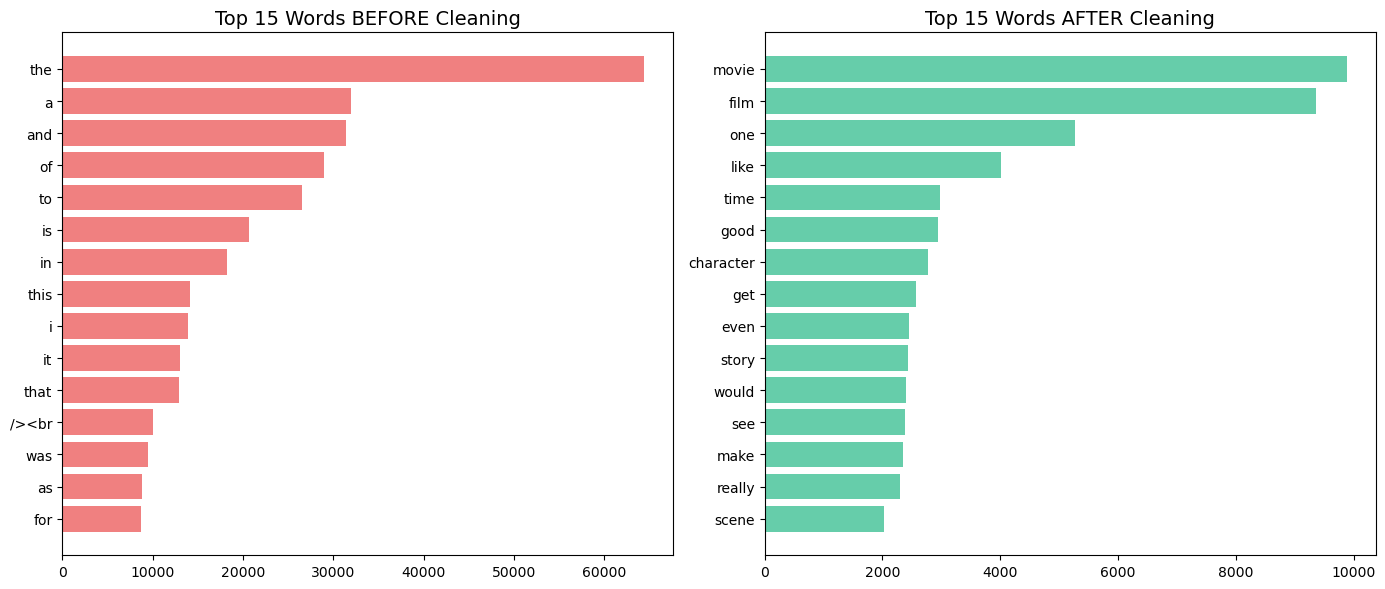

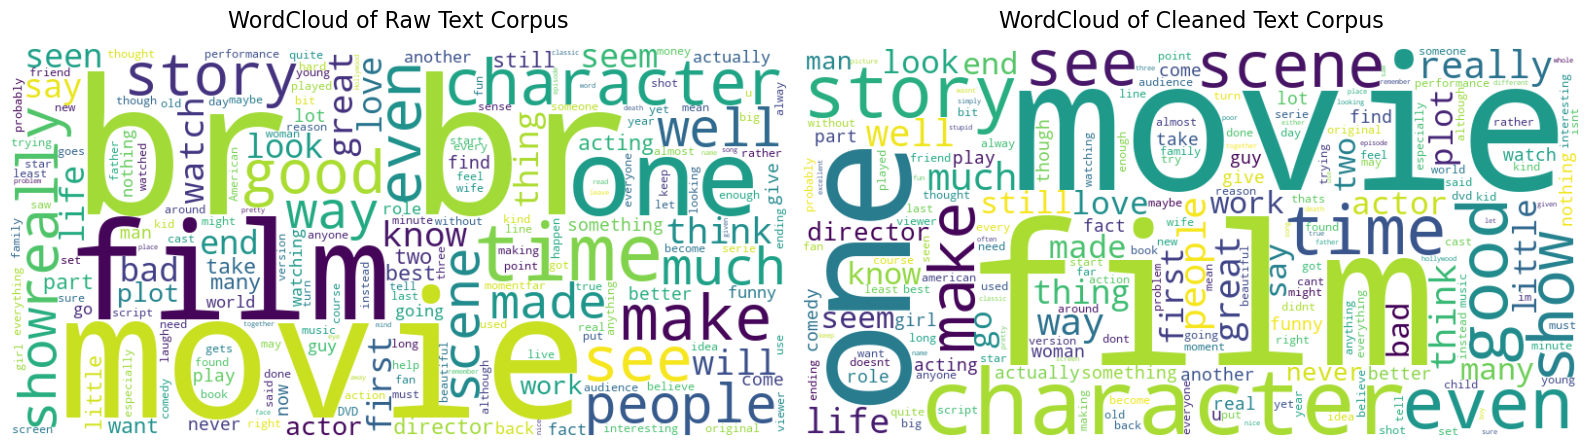

In [25]:
# adapted from google ai: https://share.google/aimode/cxuIuIlPyy0H1kK6F
!pip install wordcloud

from collections import Counter 
from wordcloud import WordCloud

# function to count words simply
def get_top_words(text_series, n=15):
    all_words = " ".join(text_series.dropna().astype(str)).lower().split()
    return Counter(all_words).most_common(n)

top_raw = get_top_words(raw_text_series)
top_cleaned = get_top_words(cleaned_text_series)

# word frequency bar charts (Before vs After)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

words_raw, counts_raw = zip(*top_raw)
axes[0].barh(words_raw, counts_raw, color='lightcoral')
axes[0].set_title("Top 15 Words BEFORE Cleaning", fontsize=14)
axes[0].invert_yaxis()  # Puts the highest count at the top

words_clean, counts_clean = zip(*top_cleaned)
axes[1].barh(words_clean, counts_clean, color='mediumaquamarine')
axes[1].set_title("Top 15 Words AFTER Cleaning", fontsize=14)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# wordcloud of the both text corpus
raw_corpus = " ".join(raw_text_series.dropna().astype(str))  # Added: Create raw_corpus
cleaned_corpus = " ".join(cleaned_text_series.dropna().astype(str))  # Added: Create cleaned_corpus

# wordcloud generation
wordcloud_raw = WordCloud(width=800, height=400, background_color='white').generate(raw_corpus)
wordcloud_clean = WordCloud(width=800, height=400, background_color='white').generate(cleaned_corpus)  # Now cleaned_corpus is defined

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# left (before cleaning)
axes[0].imshow(wordcloud_raw, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("WordCloud of Raw Text Corpus", fontsize=16, pad=15)

# right (after cleaning)
axes[1].imshow(wordcloud_clean, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("WordCloud of Cleaned Text Corpus", fontsize=16, pad=15)

plt.tight_layout()
plt.show()

**An inspection** of the cleaned dataset confirms that the pipeline correctly removed all the unnecessary information contained in the reviews. The frequency graphs indicates that all stop words, numbers, punctuation and HTML tags have been removed from the sample dataset. The word clouds further confirm that the irrelevent data present in the sample has been removed. As seen below, the percentage of irrelevent data left within the sample is minimal, with the remaining 0.3% punctuation present in the sample posing little threat to the efficacy of model training in the next step:

- HTML tags: 0 (0.0%)
- Punctuation: 162 (0.3%)
- Uppercase: 0 (0.0%)
- Numbers: 0 (0.0%)

The sample data can now be prepped for modelling using the count vectorizer for LDA and the TF-IDK vectorizer for supervised learning.  

#### 4. Model Training and Optimising
#### - **4.1. Initialising LDA**

In [28]:
# initialising vectorizer
count_vectorizer = CountVectorizer(
    min_df=2,
    max_df=0.95,
    max_features=5000
)

# transforming dataset
df1_count = count_vectorizer.fit_transform(df_sample['cleaned_review']) 

# initialise model 
lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42,
    max_iter=20
)

Using **Latent Dirichlet Allocation (LDA)** allows researchers to discover hidden themes within the review text. This process requires the data to be vectorized using the count vectorizer function before modelling. 

Machine learning models only understand numbers and cannot understand raw text, so the data must be transformed into a sparce matrix of tokens using **text vectorisation** in order for the LDA model to be used correctly. In this case, the count vectorizer is imported from sklearn and established with the following parameters:
1. - **min_df=2**: Unique words only included if they appear in more than 2 reviews. This reduces the noise in the dataset.
2. - **max_df=0.95**: Very common words appearing in more than 95% of dataset are excluded.
3. - **max_features=5000**: Helps with computational speed; limits the dataset or vocabulary to 5000 most frequent appearing words.


In this project the LDA model is imported from sklearn and initailsed using the following parameters:
1. - **n_components=10**: Group the themes in the review data into 10 groups.
2. - **max_iter=20**: The model will iterate until convergence. 
3. - **random_state=42**: This fixed seed allows other researchers to replicate your results.
  
**The next codeblocks** will verify whether the data has been vectorized correctly then fit the LDA model. 

(Murel & Kavlakoglu, 2025).

#### - **4.2. Training/fitting LDA**

In [ ]:
# verification
print (f' vocabulary size: {len(count_vectorizer.get_feature_names_out())}')
print (f' Document matrix shape: {df1_count.shape}')
print (f' Sparse matrix shape: {df1_count.shape[0]} reviews x {df1_count.shape[1]}')

In [29]:
# fitting model
lda.fit(df1_count)
print(f"   Latent topics extracted: {lda.n_components}")
print(f"   Training iterations: {lda.max_iter}")

   Latent topics extracted: 10
   Training iterations: 20


This **confirms** that the model has successfully extracted the topics in the review data after 20 training iterations. The **next section** interprets the themes extracted from the LDA model. 

#### - **4.3. Evaluating findings of LDA**

In [30]:
# source: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html
# the log-likelihood (higher is better)
log_likelihood = lda.score(df1_count)

# the perplexity (lower is better)
perplexity = lda.perplexity(df1_count)

print(f"Log-likelihood score: {log_likelihood}")
print(f"Model perplexity score: {perplexity}")

Log-likelihood score: -3710314.6880482114
Model perplexity score: 1837.3294543166692


To evaluate the mathematical quality of our Latent Dirichlet Allocation (LDA) model, we calculate two different probability metrics.
1. **log-likelihood (-3,710,314.69)**: A score closer to zero often indicates convergence. In this case, the score is severely below zero because of the size of the dataset.
2. **Model perplexity score (1,837.33)**: This value shows how well the model understands the text data. In this case, the score is high because of the diversity present in huge movie review datasets.

Next, the LDA model is evaluated by looking at the most popular words in the themes or topics found during the training process. 

(Murel & Kavlakoglu, 2025).

In [31]:
# source: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html
feature_names = count_vectorizer.get_feature_names_out()
topic_words = lda.components_

for topic in range(lda.n_components):
    top_10 = topic_words[topic].argsort()[:-11:-1]
    words = [feature_names[i] for i in top_10]  
    print(f"Topic {topic + 1}: {', '.join(words)}")

Topic 1: play, character, film, new, take, good, man, police, story, one
Topic 2: movie, get, like, one, people, dont, even, know, bad, guy
Topic 3: war, one, film, time, american, documentary, like, take, would, year
Topic 4: movie, good, one, great, really, like, see, time, would, watch
Topic 5: film, comedy, book, version, novel, mr, play, scene, musical, one
Topic 6: film, one, character, like, scene, story, movie, even, much, time
Topic 7: show, like, episode, series, time, tv, one, first, would, character
Topic 8: movie, horror, bad, acting, film, zombie, effect, worst, budget, seen
Topic 9: film, life, one, love, story, woman, family, young, man, character
Topic 10: film, one, also, first, time, great, work, role, war, set


**This indicates** that there are many overlapping generic words that need to be included into the stopword function before all topics can be successfully understood. However, before excluding the similar words like film and movie, the following themes are present in the topics so far:
1. **Topic 3**: 'War', 'american', and 'documentary' point to history and war as a main theme. 
2. **Topic 5**: Words point to literture and book to movie film adaptations as the main theme ('book', 'play', 'musical', 'version').
3. **Topic 7**: All words point to TV content ('show', 'episode', 'series', 'tv').
4. **Topic 8**: Words such as 'horror', 'bad', 'acting', 'zombie', and 'worst' points to bad horror movies.
5. **Topic 9**: Words like 'family', 'love', 'women', and 'story' could point to drama or romance.
6. **Rest of the topics (1, 2, 4, 6, 10)**: Generic words like 'also', 'even', and 'dont' severly affect the interpretation of these topics.

**Next**, the data is vectorized again with all the generic words removed using a custom stopwords function.

In [32]:
custom_stop_words = [
    'movie', 'film', 'one', 'like', 'time', 'good', 'bad', 
    'really', 'would', 'even', 'dont', 'get', 'also', 
    'character', 'story', 'scene', 'watch', 'seen', 'see'
]

# vectorize data again
count_vectorizer = CountVectorizer(
    min_df=2,
    max_df=0.95,
    max_features=5000,
    stop_words=custom_stop_words
)

# transform data again
df1_count = count_vectorizer.fit_transform(df_sample['cleaned_review']) 

# initialise model again
lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42,
    max_iter=20
)

# fit the model again
lda.fit(df1_count)

,n_components,10
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,20
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [33]:
# source: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html
feature_names = count_vectorizer.get_feature_names_out()
topic_words = lda.components_

for topic in range(lda.n_components):
    top_10 = topic_words[topic].argsort()[:-11:-1]
    words = [feature_names[i] for i in top_10]  
    print(f"Topic {topic + 1}: {', '.join(words)}")

Topic 1: many, love, life, people, director, game, american, world, much, first
Topic 2: make, acting, thing, much, plot, could, people, well, horror, know
Topic 3: monster, song, first, music, little, band, take, go, house, world
Topic 4: show, funny, think, great, make, people, thing, say, know, first
Topic 5: life, woman, show, family, people, man, real, way, police, black
Topic 6: war, man, year, best, history, people, make, made, great, life
Topic 7: show, man, he, performance, comedy, come, cast, role, musical, dr
Topic 8: book, read, novel, version, first, series, think, best, still, better
Topic 9: role, performance, great, play, love, actor, best, well, two, cast
Topic 10: series, action, zombie, fan, original, video, make, animation, fight, plot


**This indicates** that after excluding the overlapping generic words, some of key words have changed location but the following underlying themes have remained:
1. **Topic 3**: 'Song', 'music', and 'band' point to musicals as a main theme; similar to topic 5 from the previous code.
2. **Topic 5**: 'Woman', 'family', and 'police' point to dramas as a main theme; similar to topic 9.
3. **Topic 6**: 'War' and 'history' point to history and war as a main theme; similar to topic 9.
4. **Topic 8**: 'Book', 'read', and 'novel' point to literature and book to film adaptations; similar to topic 3.
5. **Topic 10**: 'Series', 'action' and 'zombie' points to TV series, similar to topic 7 and 8 from the previous code.

**The next part** of this evaluation looks at the probabilities associated with each topic found during the training process. This will provide information regarding the confidence of the themes found by the LDA model. 

(Murel & Kavlakoglu, 2025).

In [34]:
# source: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html
# transform matrix to get topic probabilities per review
doc_topic_probabilities = lda.transform(df1_count)

# extract the index of highest probability topic for each row
df_sample['Dominant_Topic'] = doc_topic_probabilities.argmax(axis=1) + 1
df_sample['Topic_Confidence'] = doc_topic_probabilities.max(axis=1)

# view the text with its assigned topic number
print(df_sample[['cleaned_review', 'Dominant_Topic', 'Topic_Confidence']].head(3))

                                          cleaned_review  Dominant_Topic  \
33553  really liked summerslam due look arena curtain...               8   
9427   many television show appeal quite many differe...               1   
199    film quickly get major chase scene ever increa...               2   

       Topic_Confidence  
33553          0.842389  
9427           0.376425  
199            0.705905  


In [35]:
# compute the average allocation for each topic
topic_shares = doc_topic_probabilities.mean(axis=0)

for i, share in enumerate(topic_shares):
    print(f"Topic {i + 1}: {share * 100:.2f}% of total dataset")

Topic 1: 10.61% of total dataset
Topic 2: 28.31% of total dataset
Topic 3: 4.13% of total dataset
Topic 4: 19.46% of total dataset
Topic 5: 6.41% of total dataset
Topic 6: 4.29% of total dataset
Topic 7: 6.00% of total dataset
Topic 8: 5.42% of total dataset
Topic 9: 9.78% of total dataset
Topic 10: 5.58% of total dataset


The output confirms that the model successfully found themes present in the vocabulary. **Topic confidence** tells the researcher the probability of that specific theme appearing in the dataset. **The average allocation** tells the researcher how much of the data is allocated to each theme. In this case, the most dominant themes in this dataset are topic 8, 1 and 2. **Additionally**, the most dominant themes are **topic 2-horror** (28.31%) and **topic 4-funny** (19.46%) while the niche themes like **topic 3-musicals** (4.13%) and **topic 6-war and history** (4.29%) make up the smaller parts of the dataset. 

**The next section** rounds off the evaluation of the LDA model by confirming whether the themes identified like history, crime and drama actually contain the reviews that the LDA model claims. In this case, three topics are verified by setting the dominant topic to each number (10, 2, 4) and setting the topic confidence to 0.70. This will display the highest confidence examples of each topic, allowing for further evaluation of the LDA model.  

(Murel & Kavlakoglu, 2025).

In [36]:
# adapted from google ai:https://share.google/aimode/iiwzpdPA6CvsTaZHE 
topic_filter = (df_sample['Dominant_Topic'] == 10) & (df_sample['Topic_Confidence'] > 0.70)
high_confidence_examples = df_sample[topic_filter]

for idx, row in high_confidence_examples.head(2).iterrows():
    print(f"Confidence Score: {row['Topic_Confidence']:.2%}")
    print(f"Review Snippet: {row['cleaned_review'][:250]}...")
    print("-" * 50)

Confidence Score: 98.33%
Review Snippet: first saw film around month ago considered interesting little stuck interest grew grew wondered whether initial boredom response actual vhs quality rather film purchased criterion dvd box set turn right second time alexander nevsky great film rousing...
--------------------------------------------------
Confidence Score: 73.11%
Review Snippet: police story brought hong kong movie modern day cinemajackie play policeman try catch drug dealer time take care young woman bad guy still take care relationship girlfriend selina brigitte linthe movie feature plenty stunt jackie also actor jackies s...
--------------------------------------------------


In [40]:
topic_filter = (df_sample['Dominant_Topic'] == 2) & (df_sample['Topic_Confidence'] > 0.70)
high_confidence_examples = df_sample[topic_filter]

for idx, row in high_confidence_examples.head(2).iterrows():
    print(f"Confidence Score: {row['Topic_Confidence']:.2%}")
    print(f"Review Snippet: {row['cleaned_review'][:250]}...")
    print("-" * 50)

Confidence Score: 70.59%
Review Snippet: film quickly get major chase scene ever increasing destruction first really bad thing guy hijacking steven seagal would beaten pulp seagals driving probably would ended whole premise movieit seems like decided make kind change movie plot plan enjoy a...
--------------------------------------------------
Confidence Score: 72.48%
Review Snippet: disappointed series lot cool graphic thats level detail went minimal always got feeling audience patronized lot seemed extremely cool going explain detail wont get anyway let show pretty picture entertain host would drop interestingsounding word spar...
--------------------------------------------------


In [39]:
topic_filter = (df_sample['Dominant_Topic'] == 4) & (df_sample['Topic_Confidence'] > 0.70)
high_confidence_examples = df_sample[topic_filter]

for idx, row in high_confidence_examples.head(2).iterrows():
    print(f"Confidence Score: {row['Topic_Confidence']:.2%}")
    print(f"Review Snippet: {row['cleaned_review'][:250]}...")
    print("-" * 50)

Confidence Score: 76.03%
Review Snippet: sad movie really nothing happens movie script bad guess theyve copypaste first page page producer must thought let create hollywood movie belgium didnt succeed third week running antwerp brussels h something past really good movie belgium like daens ...
--------------------------------------------------
Confidence Score: 96.31%
Review Snippet: actually didnt start watching show came fx bored nothing watch saw show rerun premiering decided watch upset watched show first aired tv loved show muchfinally show everyone enjoy remember full house family matter step step okay show funny enough wou...
--------------------------------------------------


The final verification confirms that the trained LDA model aligns with how the themes were interpretted. 

- **Topic 10 (Series and action)**: The model demonstrates precision as it captures a review that discusses Alexander Nevsky (associated with war-based action films) with a **98.33% confidence score**. Another review based on a police action movie was also captured with **73.11% confidence**.
- **Topic 2**: The model found text that evaluates the story elements associated with certain films.
- **Topic 4 (Comedy)**: The model found audience reactions to comedic films in the reviews. One reviewer praised a funny TV show by stating "loved show much... show funny enough". This cleanly aligns with the theme, as evident due to a high **96.31% confidence score**.
(Murel & Kavlakoglu, 2025).

Overall, this shows that the LDA model performed well and successfully categorised certain reviews under the correct themes. **The next section** revolves around using supervised learning algorithms on text review data to predict  

#### 5. Supervised Learning Algorithms 
#### - **5.1. Preprocessing text data**

**Before fitting any model** to this dataset, certain factors must be addressed for the process to run effectively. **First**, the target column in this dataset must be label encoded (1 and 0) for classification algorithms to perform effectively. **Second**, the data must be split into training and test groups before vectorizing to prevent data leakage. 

(James et al., 2023).

In [42]:
# encoding the data
df_sample['sentiment_encoded'] = df_sample['sentiment'].map({
    'negative': 0,
    'positive': 1
})

# seperating the data 
X = df_sample['cleaned_review']
y = df_sample['sentiment_encoded']

# splitting data into test and training groups
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify= y
)

In [44]:
# vectorizing the data
tfidf = TfidfVectorizer(
    max_features=5000,  # Top 5000 words
    min_df=1,
    max_df=0.95
)

# only run fit_transform on training data to prevent data leakage
X_train_tfidf = tfidf.fit_transform(X_train)  
X_test_tfidf = tfidf.transform(X_test)

#### - **5.2. Fitting the models**

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

# logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
y_proba_lr = lr.predict_proba(X_test_tfidf)[:, 1]

# SVM
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
y_proba_svm = svm.predict_proba(X_test_tfidf)[:, 1]

# naive bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
y_proba_nb = nb.predict_proba(X_test_tfidf)[:, 1]

**Researchers** split datasets into two parts when making predictions. One group for fitting and one group is used for evaluation. The training and test scores from these two groups allows researchers to gauge the performance of their models. In this case, the following models are being trained:

1. **Logistic Regression**: This model is often used as the baseline model in classification tasks due to its interpretibility and ease. This produces odds ratios that tells researchers about the target outcome. 
- **> 1.0** = positive predictor (increases the odds of a positive sentiment review)
- **< 1.0** = negative predictor (increases the odds of a negative sentiment review)

2. **Support Vector Classifier (SVC)**: This model is used because of its ability to seperate data classes by finding the optimal hyperplane. It maximizes the margin between different classes using support vectors, thereby allowing class seperation and better model performance.

3. **Multinomial Naive Bayes**: This model is designed for text classification because it is based on word counts or frequencies. It utilises the Bayes' Theorem to find the probability of a review being either positive or negative.

(James et al., 2023).

#### - **5.3. Model Coefficients**

In [47]:
# adapted from source: https://medium.com/@dvdhartsman/extracting-coefficients-and-feature-names-from-scikit-learn-pipelines-331d578b8450
# get 5,000 words from your TF-IDF vectorizer
words = tfidf.get_feature_names_out()

# logistic regression weights
lr_df = pd.DataFrame({'Word': words, 'Val': lr.coef_[0]})
print("LR Positive:", lr_df.sort_values(by='Val', ascending=False)['Word'].head(5).tolist())
print("LR Negative:", lr_df.sort_values(by='Val', ascending=True)['Word'].head(5).tolist())

# SVM weights
svm_coef = svm.coef_.toarray()[0] if hasattr(svm.coef_, "toarray") else svm.coef_[0]
svm_df = pd.DataFrame({'Word': words, 'Val': svm_coef})
print("SVM Positive:", svm_df.sort_values(by='Val', ascending=False)['Word'].head(5).tolist())
print("SVM Negative:", svm_df.sort_values(by='Val', ascending=True)['Word'].head(5).tolist())

# feature probabilities for naive bayes
nb_diff = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
nb_df = pd.DataFrame({'Word': words, 'Val': nb_diff})
print("NB Positive:", nb_df.sort_values(by='Val', ascending=False)['Word'].head(5).tolist())
print("NB Negative:", nb_df.sort_values(by='Val', ascending=True)['Word'].head(5).tolist())

LR Positive: ['great', 'best', 'excellent', 'amazing', 'love']
LR Negative: ['bad', 'worst', 'waste', 'awful', 'nothing']
SVM Positive: ['great', 'best', 'excellent', 'favorite', 'fun']
SVM Negative: ['worst', 'bad', 'waste', 'nothing', 'awful']
NB Positive: ['matthau', 'underrated', 'amazing', 'superb', 'outstanding']
NB Negative: ['waste', 'worst', 'awful', 'horrible', 'terrible']


- **Logistic regression** and **SVM**: Both these models rely on adjectives like 'best', 'great' and 'excellent' to seperate the reviews into positive and negative sentiment.
- **Naive bayes**: This model isolates words like 'underrated' and 'amazing' to seperate the reviews into positive and negative sentiment. **Additionally**, there appears to be an actors name ('Matthau') in the positive sentiment section, meaning that this actor could be consistently mentioned in positive reviews; this is highly specific to this dataset (noise).

#### - **5.4. Performance analysis**

In [48]:
print("logistic regression")
print(f"Train: {lr.score(X_train_tfidf, y_train):.2%}")
print(f"Test:  {lr.score(X_test_tfidf, y_test):.2%}\n")

print("SVM")
print(f"Train: {svm.score(X_train_tfidf, y_train):.2%}")
print(f"Test:  {svm.score(X_test_tfidf, y_test):.2%}\n")

print("naive bayes")
print(f"Train: {nb.score(X_train_tfidf, y_train):.2%}")
print(f"Test:  {nb.score(X_test_tfidf, y_test):.2%}")

logistic regression
Train: 93.27%
Test:  86.00%

SVM
Train: 96.47%
Test:  85.50%

naive bayes
Train: 90.72%
Test:  83.90%


**Overall**, the accuracy scores show that the models perform relatively well on the dataset, with all models achieving a strong test accuracy. The baseline **logistic regression** model is the best performer with a high test accuracy and more stable training accuracy as opposed to the other two models. 

**These results** show that the SVM model is overfitting the training data compared to the test data (96.47% vs. 85.50%). This means that the model is memerising too much of the noise present in the training group. **On the other hand**, the naive bayes model underfits compared to the other two models because it has the lowest training score and lowest test score. 

In [49]:
# precision = how many correct positive predicted
# recall = how many true positives caught
# f1-score = how good is model at not getting false positives
# accuracy = how many true values predicted correctly

# classification reports
from sklearn.metrics import classification_report

print("logistic regression")
print(classification_report(y_test, y_pred_lr))

print("SVM")
print(classification_report(y_test, y_pred_svm))

print("naive bayes")
print(classification_report(y_test, y_pred_nb))

=== Logistic Regression Performance ===
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       496
           1       0.85      0.88      0.86       504

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000


=== Support Vector Machine Performance ===
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       496
           1       0.86      0.85      0.86       504

    accuracy                           0.85      1000
   macro avg       0.85      0.86      0.85      1000
weighted avg       0.86      0.85      0.86      1000


=== Naive Bayes Performance ===
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       496
           1       0.85      0.83      0.84       504

    accuracy                           0.84      1000
   macro av

The evaluation metrics for all three algorithms show high predictive performance, with **logistic regression** yielding the best results. 

- **Logistic Regression (86.00% Accuracy)**: This classifier has a very good precision and recall balance. On negative sentiment it achieved a precision of **0.87**, so when it identifies a review as negative, it is correct 87% of the time. On the other hand, positive sentiment got a recall of **0.88**, so it caught 88% of all positive reviews in the dataset.

- **Support Vector Machine (85.00% Accuracy)**: This was almost identical to the logistic regression classification report but underperformed slightly in comparison. 

- **Multinomial Naive Bayes (84.00% Accuracy)**: While this model is very simple it still performed competitively with the other two models. This model is more effective at finding negative reviews (**0.85**) over positive ones (**0.83**).

In [50]:
from sklearn.metrics import confusion_matrix

print("logistic regression")
print(confusion_matrix(y_test, y_pred_lr))

print("SVM")
print(confusion_matrix(y_test, y_pred_svm))

print("naive bayes")
print(confusion_matrix(y_test, y_pred_nb))

logistic regression
[[419  77]
 [ 63 441]]
SVM
[[425  71]
 [ 74 430]]
naive bayes
[[423  73]
 [ 88 416]]


**The confusion matrices** provide the number of correct and incorrect classifications made by each model on the test dataset: 

**Logistic Regression**: 
-  **True Negatives:** 419 reviews were correctly identified.
- **True Positives:** 441 reviews were correctly identified.
- **False Positives (77) and False Negatives (63):** This model has a lowest number of missed positive reviews (63). This aligns with the findings earlier (recall = 88%).

**Support Vector Machine (SVM)**: 
- **True Negatives:** 425 reviews were correctly identified.
- **True Positives:** 430 reviews were correctly identified. 
- **False Positives (71) and False Negatives (74):** The error rates are almost identical on both sides. 

**Multinomial Naive Bayes**: 
- **True Negatives:** 423 reviews were correctly identified.
- **True Positives:** 416 reviews were correctly identified.
- **False Positives (73) and False Negatives (88):** Had the highest number of False Negatives (88); it was very likely that this model mistakes a positive review for a negative one. This confirms that this model underperforms compared to the other models.

(Müller & Guido, 2016).

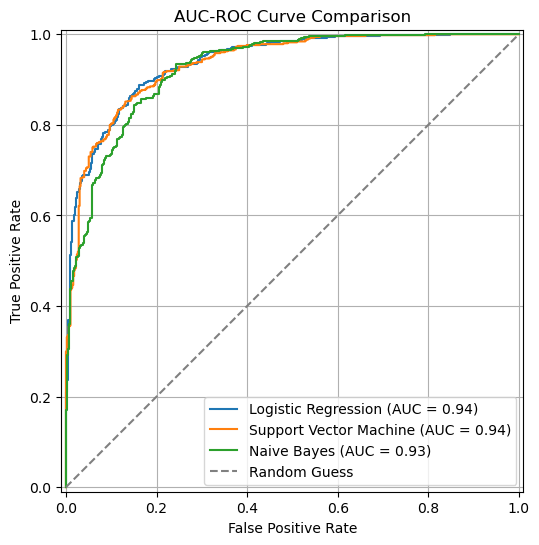

In [51]:
# AUC-ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

# plotting each model
RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test, y_proba_svm, ax=ax, name='Support Vector Machine')
RocCurveDisplay.from_predictions(y_test, y_proba_nb, ax=ax, name='Naive Bayes')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')

ax.set_title('AUC-ROC Curve Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True)

plt.show()

**This comparison illustrates the following:**

**Logistic Regression (AUC = 0.94)**: This model has the highest true positive rate as seen with the spike in the initial stage. Therefore, if the aim was to minimise false positives then this model would be chosen.

**Support Vector Machine (AUC = 0.94)**: This model is highly similar to the logistic regression model because the lines constantly intersect.

**Multinomial Naive Bayes (AUC = 0.93)**: This model underperforms compared to the other two models, with the curve sitting lower in the false positive range. 

(Müller & Guido, 2016).

#### - **5.5. Evaluation**

- **Unsupervised learning**

| Extracted Theme | Top Associated Keywords | Corpus Share (%) | Key Document Example | Model Confidence |
| :--- | :--- | :---: | :--- | :---: |
| **Topic 2: Horror & Plot Critique** | `make`, `acting`, `plot`, `horror`, `know` | **28.31% (DOMINANT)** | Action tropes, chase scenes, and plot structure | 70.59% |
| **Topic 4: Comedy & TV Shows** | `show`, `funny`, `think`, `great`, `people` | **19.46%** | TV broadcast reruns and lighthearted content | 96.31% |
| **Topic 1: General Commentary** | `many`, `love`, `life`, `people`, `director` | 10.61% | Conversational text spanning multiple points | 37.64% |
| **Topic 9: Performance Review** | `role`, `performance`, `great`, `play`, `actor` | 9.78% | Direct commentary evaluating acting quality | — |
| **Topic 5: Crime Dramas** | `life`, `woman`, `family`, `police`, `real` | 6.41% | True crime or procedural narratives | 73.11% |
| **Topic 7: Cast & Comedy** | `show`, `man`, `performance`, `comedy`, `cast` | 6.00% | Sitcoms, theatrical plays, or ensemble casts | — |
| **Topic 10: Action & Sub-genres** | `series`, `action`, `zombie`, `fan`, `original` | 5.58% | Combat-heavy blockbusters or zombie media | — |
| **Topic 8: Literary Adaptations** | `book`, `read`, `novel`, `version`, `series` | 5.42% | Reviews comparing a film back to its text source | 84.24% |
| **Topic 6: War & History** | `war`, `man`, `year`, `best`, `history` | 4.29% | Period pieces and historical war epics | **98.33%** |
| **Topic 3: Musicals & Audio** | `monster`, `song`, `music`, `little`, `band` | 4.13% | Audio tracks or campy creature features | — |

*Model Fit Statistics: Log-Likelihood = -3,710,314.69 | Perplexity = 1,837.33*


**The results show** that the LDA model successfully extracted the underlying themes present in the review dataset (corpus). Generic words were filtered out to provide the best possible review data to the model. This allowed the model to identify niche topics in the dataset such as **Musicals (Topic 3)** and **War & History (Topic 6)**. 

**The document allocation probabilities** show that the most weighted themes are relatd to audience critiques (almost **48% of the total dataset**). Smaller more unique themes like historical war and action content represents about **4.29%** of the text data. This shows that majority of the reviews revolve around generalised critiques rather than specific genre critiques. 

**Furthermore**, thematic accuracy shows that the themes created based on the reviews are not random; instead they theme selection is systematic, depending on the reviews within the dataset. For example, the accuracy score for **War & History (Topic 6)** was more than 90%, and the score for topic **Crime Dramas (Topic 5)** was more than 70%. This shows that the LDA model successfully seperated the review data based on their underlying themes. 

(Murel & Kavlakoglu, 2025).

- **Supervised learning**

| Model | Training score | Test score | Tuning | CV score | Final accuracy |
| :--- | :---: | :---: | :--- | :---: | :---: |
| **Logistic Regression** | 93.27% | **86.00%** | *None* | — | **86.00% (WINNER)** |
| **Support Vector Classifier** | 96.47% | 85.50% | *None* | — | 85.50% |
| **Multinomial Naive Bayes** | 90.72% | 83.90% | *None* | — | 83.90% |

**The results** show that descriptive vocabulary like 'bad', 'good', and 'awful' are the main seperators of positive and negative sentiment across the supervised learning algorithms. 

**Initial training and test scores** indicate that certain models struggle with overfitting. The **SVC** model showed an initial **training score of 96.47%** and a **test score of 85.50%**, indicating that the model focused too much on the noise present in the training dataset. **In comparison**, the  **multinomial naive bayes model** showed slight signs of underfitting with a training score of **90.72%** and a test score of **85.50%**. 

**Overall**, the **logistic regression** model achieved the highest test accuracy (86%) while maintaining a good training score. This model also had the **highest positive recall of 88%**, meaning it minimizes critical misses. This is evident from the confusion matrix, showing that the model identified **441 true positive reviews** and **419 true negative reviews** with only **63 false negatives** and **77 false positives** out of the **1,000 total test documents**. This great performance could be attributed to logistic regressions simplicity and knack for modelling binary classification data. 

(Müller & Guido, 2016).

#### 6. Conclusion
#### - **6.1.Recommendations**

**The modelling**processes taken in this notebook can be enhanced by:
- **Advanced models**: Using more advanced deep learning models may produce even higher predictive accuracy (Deep learning models). 
- **Hyperparameter tuning**: The supervised learning models could have bee optimised to increase the accuracy scores. 
- **Advanced NLP libraries**: Libraries like spaCY could be used to imporve tokenizations, lemmitization and other preprocessing steps (Verma et al. 2024).
- **Larger sample**: A larger sample (> 10,000) can be used for modelling to improve generalisation. 

(James et al., 2023).

#### 7. References

Caldwell, S. (2013). Statistics unplugged (4th ed.). Cengage Learning.

Dalianis, H. (2018). Evaluation metrics and evaluation. In H. Dalianis (Ed.), Clinical text mining: Secondary use of electronic patient records (pp. 45–53). Springer. https://doi.org/10.1007/978-3-319-78503-5_6

Hastie, T., Tibshirani, R., & Friedman, R. (2017). The elements of statistical learning: Data mining, inference, and prediction (2nd ed.). Springer.

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in Python. Springer. 

Müller, A. C., & Guido, S. (2016). Introduction to machine learning with Python: A guide for data scientists. O'Reilly Media.

Murel, J. & Kavlakoglu, E. 2025. What is Latent Dirichlet allocation? [Online] IBM. Available at: https://www.ibm.com/think/topics/latent-dirichlet-allocation [Accessed 22 June 2026].

Verma, P., Bansal, D., Gupta, S., Bansal, S. & Singh, T. 2024. Sentiment Analysis Approach through Artificial Intelligence Based Machine Learning for Movie Review. In: 2024 International Conference on Intelligent Systems for Cybersecurity (ISCS) [Online]. IEEE, pp. 1-6. Available at: https://ieeexplore.ieee.org/document/10581227 [Accessed 22 June 2026].